<a id='notebook-top'></a>

# Time-distance Diagrams of Chromospheric Fibrils and their Hotter Counterparts  
---
This notebook shows the time-distance diagrams of the chromospheric fibrils and their hotter counterparts along the slits placed in [Figure 2](./all_channel_layout.ipynb). 

Note: The internal hyperlink only works on [GitHub Pages](https://yjzhu-solar.github.io/DKIST_SolO_Fibril/ipynb_html/spacetime_vbi_aia_iris.html) or [nbviewer](https://nbviewer.org/github/yjzhu-solar/DKIST_SolO_Fibril/blob/master/ipynb/ms_plot/spacetime_vbi_aia_iris.ipynb). Do not click when viewing the notebook on GitHub.

## Import libraries and plotting configurations

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib import animation
import sunpy
import sunpy.map
from sunpy.coordinates import get_earth
import dkist 
import dask.array as da
import h5py
from astropy.time import Time
from astropy.io import ascii, fits
from astropy.wcs import WCS
from astropy.visualization import (ImageNormalize, 
                    SqrtStretch, AsinhStretch)
import astropy.units as u
from ndcube import NDCube
from scipy.io import readsav
from skimage import measure
import skimage.measure.profile
from skimage.transform import rescale
import matplotlib.lines as mlines
import cv2


import importlib
import slit_interactive
importlib.reload(slit_interactive)
from slit_interactive import (SlitPick, plot_slit_position,
        remove_background, generate_slit_data_from_points,
        generate_straight_slit_data)

In [2]:
ms_style_dict = {'text.usetex': True, 'font.family': 'serif', 'axes.linewidth': 1.2,
                 'xtick.major.width': 1.2, 'xtick.major.size': 4,
                 'ytick.major.width': 1.2, 'ytick.major.size': 4,
                 'xtick.minor.width': 1.2, 'xtick.minor.size': 2,
                 'ytick.minor.width': 1.2, 'ytick.minor.size': 2,
                 'xtick.direction': 'in', 'ytick.direction': 'in',
                 'text.latex.preamble': r'\usepackage[T1]{fontenc}'
                 r'\usepackage{amsmath}' r'\usepackage{siunitx}'
                 r'\sisetup{detect-all=True}' r'\usepackage{fixltx2e}'}

## Load preprocessed data

In [3]:
file_Halpha_pr = h5py.File("../../data/pid_1_123_aux/plot_ready/Halpha_BLZNL_pr.hdf5")
Halpha_pr_set = file_Halpha_pr["vbi_img"]
# Halpha_pr_da = da.from_array(Halpha_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Halpha_date_obs = Time(ascii.read("../../data/pid_1_123_aux/plot_ready/Halpha_BLZNL_date_avg.txt")["DATE-AVG"])

In [4]:
Halpha_pr_rebin = np.load("../../data/pid_1_123_aux/plot_ready/rebin/Halpha_BLZNL_pr_rebin_4.npy")

In [5]:
file_Hbeta_pr = h5py.File("../../data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_pr.hdf5")
Hbeta_pr_set = file_Hbeta_pr["vbi_img"]
# Hbeta_pr_da = da.from_array(Hbeta_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Hbeta_date_obs = Time(ascii.read("../../data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_date_avg.txt")["DATE-AVG"])

In [6]:
Hbeta_pr_rebin = np.load("../../data/pid_1_123_aux/plot_ready/rebin/Hbeta_BJOLO_pr_rebin_4.npy")

In [7]:
file_aia171_pr_dset = h5py.File("../../data/pid_1_123_aux/plot_ready/AIA_171_pr.hdf5")
aia171_pr_set = file_aia171_pr_dset["aia_171_img"]
aia171_pr_da = da.from_array(aia171_pr_set, chunks=(1, (4096 - 128*2)//8, (4096 - 128*2)//8))
aia171_pr_da = aia171_pr_da.compute()
aia171_date_obs = Time(ascii.read("../../data/pid_1_123_aux/plot_ready/AIA_171_date_obs.txt")["date_obs"])

In [8]:
file_irissji_pr_dset = h5py.File("../../data/pid_1_123_aux/plot_ready/IRISSJI_1400_nowow_pr.hdf5")
irissji_pr_set = file_irissji_pr_dset["irissji_1400_nowow_img"]
irissji_pr_da = da.from_array(irissji_pr_set, chunks=(1, (4096 - 128*2)//8, (4096 - 128*2)//8))
irissji_date_obs = Time(ascii.read("../../data/pid_1_123_aux/plot_ready/IRISSJI_1400_date_obs.txt")["date_obs"])
irissji_pr_da = irissji_pr_da.compute()

In [9]:
file_CaIIK_pr = h5py.File("../../data/pid_1_123_aux/plot_ready/CaIIK_BZPOW_pr.hdf5")
CaIIK_pr_set = file_CaIIK_pr["vbi_img"]
CaIIK_pr_da = da.from_array(CaIIK_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
CaIIK_date_obs = Time(ascii.read("../../data/pid_1_123_aux/plot_ready/CaIIK_BZPOW_date_avg.txt")["DATE-AVG"])

In [10]:
# CaIIK_pr_rebin = np.nanmean(CaIIK_pr_da.reshape([CaIIK_pr_da.shape[0],
#                     CaIIK_pr_da.shape[1]//4, 4,
#                     CaIIK_pr_da.shape[2]//4, 4]), axis=(2,4))
# CaIIK_pr_rebin = CaIIK_pr_rebin.compute()

In [11]:
# np.save("../../data/pid_1_123_aux/plot_ready/rebin/CaIIK_BZPOW_pr_rebin_4.npy", CaIIK_pr_rebin)
CaIIK_pr_rebin = np.load("../../data/pid_1_123_aux/plot_ready/rebin/CaIIK_BZPOW_pr_rebin_4.npy")

In [12]:
file_hrieuv_proj_dset = h5py.File("../../data/pid_1_123_aux/plot_ready/HRIEUV_nowow_pr.hdf5")
hrieuv_proj_pr_set = file_hrieuv_proj_dset["hrieuv_nowow_img"]
hrieuv_proj_pr_da = da.from_array(hrieuv_proj_pr_set, chunks=(1, (4096 - 128*2)//8, (4096 - 128*2)//8))
hrieuv_date_obs = Time(ascii.read("../../data/pid_1_123_aux/plot_ready/HRIEUV_date_ear.txt")["date_ear"])
hrieuv_proj_pr_da = hrieuv_proj_pr_da.compute()

In [13]:
eui_map_no_proj_array_crop = np.load("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/hri_no_proj_array_crop.npy")

In [14]:
eui_map_no_proj_array_crop.shape

(224, 245, 360)

## Crop the image sequences

In [15]:
aia_start_index = 3

Halpha_start_index = np.argmin(np.abs(Halpha_date_obs - aia171_date_obs[aia_start_index]))
Halpha_end_index = np.argmin(np.abs(Halpha_date_obs - aia171_date_obs[-1]))

Hbeta_start_index = np.argmin(np.abs(Hbeta_date_obs - aia171_date_obs[aia_start_index]))
Hbeta_end_index = np.argmin(np.abs(Hbeta_date_obs - aia171_date_obs[-1]))

CaIIK_start_index = np.argmin(np.abs(CaIIK_date_obs - aia171_date_obs[aia_start_index]))
CaIIK_end_index = np.argmin(np.abs(CaIIK_date_obs - aia171_date_obs[-1]))

irissji_start_index = np.argmin(np.abs(irissji_date_obs - aia171_date_obs[aia_start_index]))
irissji_end_index = np.argmin(np.abs(irissji_date_obs - aia171_date_obs[-1]))

hrieuv_start_index = np.argmin(np.abs(hrieuv_date_obs - aia171_date_obs[aia_start_index]))
hrieuv_end_index = np.argmin(np.abs(hrieuv_date_obs - aia171_date_obs[-1]))

Halpha_date_diff = np.abs(np.nanmean(np.diff(Halpha_date_obs))).to_value(u.s)
Halpha_time_extent = np.array([-0.5, Halpha_end_index - Halpha_start_index + 1 - 0.5])*Halpha_date_diff + \
    (Halpha_date_obs[Halpha_start_index] - aia171_date_obs[aia_start_index]).to_value(u.s)

Hbeta_date_diff = np.abs(np.nanmean(np.diff(Hbeta_date_obs))).to_value(u.s)
Hbeta_time_extent = np.array([-0.5, Hbeta_end_index - Hbeta_start_index + 1 - 0.5])*Hbeta_date_diff + \
    (Hbeta_date_obs[Hbeta_start_index] - aia171_date_obs[aia_start_index]).to_value(u.s)

CaIIK_date_diff = np.abs(np.nanmean(np.diff(CaIIK_date_obs))).to_value(u.s)
CaIIK_time_extent = np.array([-0.5, CaIIK_end_index - CaIIK_start_index + 1 - 0.5])*CaIIK_date_diff + \
    (CaIIK_date_obs[CaIIK_start_index] - aia171_date_obs[aia_start_index]).to_value(u.s)

irissji_date_diff = np.abs(np.nanmean(np.diff(irissji_date_obs))).to_value(u.s)
irissji_time_extent = np.array([-0.5, irissji_end_index - irissji_start_index + 1 - 0.5])*irissji_date_diff + \
    (irissji_date_obs[irissji_start_index] - aia171_date_obs[aia_start_index]).to_value(u.s)

hrieuv_date_diff = np.abs(np.nanmean(np.diff(hrieuv_date_obs))).to_value(u.s)
hrieuv_time_extent = np.array([-0.5, hrieuv_end_index - hrieuv_start_index + 1 - 0.5])*hrieuv_date_diff + \
    (hrieuv_date_obs[hrieuv_start_index] - aia171_date_obs[aia_start_index]).to_value(u.s)

aia_date_diff = np.abs(np.nanmean(np.diff(aia171_date_obs))).to_value(u.s)
aia_time_extent = np.array([-0.5, len(aia171_date_obs[aia_start_index:]) - 1 - 0.5])*aia_date_diff

In [16]:
dkist_vbi_target_header = fits.getheader("../../data/pid_1_123_aux/plot_ready/dkist_target_wcs_header_before_crop.fits",
                                        ignore_missing_simple=True)

pixel_scale = dkist_vbi_target_header["CDELT1"]/3600*np.pi/180*get_earth(dkist_vbi_target_header["DATE-AVG"]).radius.to_value(u.Mm)*4

In [17]:
hrieuv_noproj_header = fits.getheader("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/hri_nocrop_noproj_wcs.fits",
                                        ignore_missing_simple=True)
pixel_scale_p = np.deg2rad(hrieuv_noproj_header["CDELT1"])*hrieuv_noproj_header["DSUN_OBS"]/1e6

## Generate time-distance diagrams

In [18]:
def get_slit_data(
    x_select, y_select, line_width,
    x_select_p, y_select_p, line_width_p,
    halpha_cube=Halpha_pr_rebin[Halpha_start_index:Halpha_end_index, :, :].transpose(1, 2, 0),
    hbeta_cube=Hbeta_pr_rebin[Hbeta_start_index:Hbeta_end_index, :, :].transpose(1, 2, 0),
    CaIIK_cube=CaIIK_pr_rebin[CaIIK_start_index:CaIIK_end_index, :, :].transpose(1, 2, 0),
    hrieuv_proj_cube=hrieuv_proj_pr_da[hrieuv_start_index:hrieuv_end_index, :, :].transpose(1, 2, 0),
    aia_cube=aia171_pr_da.transpose(1, 2, 0),
    irissji_cube=irissji_pr_da[irissji_start_index:irissji_end_index, :, :].transpose(1, 2, 0),
    hrieuv_noproj_cube = eui_map_no_proj_array_crop[:,:,hrieuv_start_index:hrieuv_end_index],
    bg_kwargs={"method": "median"},
    ):

    slit_halpha_result = generate_slit_data_from_points(
        x_select, y_select, halpha_cube, "NDArray", line_width=line_width,
    )
    slit_halpha_intensity, _ = remove_background(
        slit_halpha_result["slit_intensity"], **bg_kwargs,
    )

    slit_hbeta_result = generate_slit_data_from_points(
        x_select, y_select, hbeta_cube, "NDArray", line_width=line_width,
    )

    slit_hbeta_intensity, _ = remove_background(
        slit_hbeta_result["slit_intensity"], **bg_kwargs,
    )

    slit_CaIIK_result = generate_slit_data_from_points(
        x_select, y_select, CaIIK_cube, "NDArray", line_width=line_width,
    )

    slit_CaIIK_intensity, _ = remove_background(
        slit_CaIIK_result["slit_intensity"], **bg_kwargs,
    )

    slit_aia_result = generate_slit_data_from_points(
        x_select / 2, y_select / 2, aia_cube, "NDArray", line_width=line_width // 2,
    )
    slit_aia_intensity, _ = remove_background(
        slit_aia_result["slit_intensity"], **bg_kwargs,
    )

    slit_irissji_result = generate_slit_data_from_points(
        x_select / 2, y_select / 2, irissji_cube, "NDArray", line_width=line_width // 2,
    )
    slit_irissji_intensity, _ = remove_background(
        slit_irissji_result["slit_intensity"], **bg_kwargs,
    )

    slit_hrieuv_proj_result = generate_slit_data_from_points(
        x_select / 2, y_select / 2, hrieuv_proj_cube, "NDArray", line_width=line_width // 2,
    )

    slit_hrieuv_proj_intensity, _ = remove_background(
        slit_hrieuv_proj_result["slit_intensity"], **bg_kwargs,
    )

    slit_hrieuv_noproj_result = generate_slit_data_from_points(
        x_select_p, y_select_p, hrieuv_noproj_cube, "NDArray", line_width=line_width_p,
    )

    slit_hrieuv_noproj_intensity, _ = remove_background(
        slit_hrieuv_noproj_result["slit_intensity"], **bg_kwargs,
    )

    length_extent = slit_halpha_result["pixel_distance_interp"][np.r_[0, -1]] * pixel_scale
    length_extent_p = slit_hrieuv_noproj_result["pixel_distance_interp"][np.r_[0, -1]] * pixel_scale_p

    return ((
        slit_hbeta_intensity,
        slit_halpha_intensity,
        slit_CaIIK_intensity,
        slit_irissji_intensity,
        slit_aia_intensity,
        slit_hrieuv_noproj_intensity,
        slit_hrieuv_proj_intensity,
    ),
    (length_extent, length_extent_p))



In [19]:
x_select_df1  = np.array(
    [562.8, 512.5, 476.9, 427.0]
)

y_select_df1 = np.array(
    [459.5, 478.0, 486.0, 483.3]
)

x_select_df1_p = np.array(
    [122, 99.8]
)

y_select_df1_p = np.array(
    [113.5, 93.9]
)

#====================================================================================
x_select_df2 = np.array(
    [380, 336, 246]
)

y_select_df2 = np.array(
    [755, 775, 783]
)

x_select_df2_p = np.array(
    [92.7, 83.3, 72.9]
)

y_select_df2_p = np.array(
    [197.6, 190.3, 175.5]
)

#====================================================================================
x_select_df3 = np.array(
    [551.5, 533.4, 499.7,]
)

y_select_df3 = np.array(
    [626.0, 715.1, 882.8,]
)

x_select_df3_p = np.array(
    [127.4, 135.3, 152.6*0.75 + 0.25*183.1]
)

y_select_df3_p = np.array(
    [144.4, 164.8, 180.2*0.75 + 0.25*198.3]
)

#====================================================================================
x_select_df4 = np.array(
    [426, 350.6, 283.6]
)

y_select_df4 = np.array(
    [563.8, 535.9, 498.0]
)

x_select_df4_p = np.array(
    [98.1, 85.6, 80.6]
)

y_select_df4_p = np.array(
    [127.8, 112.4, 100.3]
)

#====================================================================================
x_select_ef1 = np.array(
    [396, 358, 322.4, 282, 242, 210, 178]
)

y_select_ef1 = np.array(
    [461, 433.5, 399, 346, 287, 232, 177]
)

x_select_ef1_p = np.array(
    [105.5, 100.1, 83.6, 78.3, 74.7]
)

y_select_ef1_p = np.array(
    [100.8, 93.3, 60.7, 45.4, 33.5]
)

#====================================================================================
x_select_ef2 = np.array(
    [459.8, 402.4, 337.7, 317.6]
)

y_select_ef2 = np.array(
    [375.1, 301.9, 207.0, 168.3]
)

x_select_ef2_p = np.array(
    [120.5, 97.9]
)

y_select_ef2_p = np.array(
    [82.6, 35.1]
)



In [40]:
slit_data_df1, slit_length_extent_df1 = get_slit_data(
    x_select_df1, y_select_df1, 10,
    x_select_df1_p, y_select_df1_p, 2,
)

slit_data_df2, slit_length_extent_df2 = get_slit_data(
    x_select_df2, y_select_df2, 10,
    x_select_df2_p, y_select_df2_p, 2,
)

slit_data_df3, slit_length_extent_df3 = get_slit_data(
    x_select_df3, y_select_df3, 10,
    x_select_df3_p, y_select_df3_p, 2,
)

slit_data_df4, slit_length_extent_df4 = get_slit_data(
    x_select_df4, y_select_df4, 10,
    x_select_df4_p, y_select_df4_p, 2,
)

slit_data_ef1, slit_length_extent_ef1 = get_slit_data(
    x_select_ef1, y_select_ef1, 10,
    x_select_ef1_p, y_select_ef1_p, 2,
)

slit_data_ef2, slit_length_extent_ef2 = get_slit_data(
    x_select_ef2, y_select_ef2, 10,
    x_select_ef2_p, y_select_ef2_p, 2,
)

In [21]:
def plot_slit_data(
    slit_data,
    axes,
    length_extent,
    time_extents=[
        Hbeta_time_extent,
        Halpha_time_extent,
        CaIIK_time_extent,
        irissji_time_extent,
        aia_time_extent,
        hrieuv_time_extent
    ],
    norms=[None, None, None, None, None],
    ):

    cmap = ("Greys_r", "Greys_r", "bone", "irissji1400", "sdoaia171", "sdoaia171", "sdoaia171")

    for ii in range(6):
        axes[ii].imshow(
        slit_data[ii], cmap=cmap[ii], origin="lower", interpolation="none",
        norm=norms[ii],
        aspect="auto",
        extent=[*time_extents[ii], *length_extent[0]],
    )

    axes[6].imshow(
        slit_data[6], cmap=cmap[6], origin="lower", interpolation="none",
        norm=norms[6],
        aspect="auto",
        extent=[*time_extents[5], *length_extent[1]],
    )

    return None

In [22]:
def percentile_norm(vmin, vmax, data, asinh=0.4):
    if asinh is None:
        return ImageNormalize(
            vmin=np.nanpercentile(data, vmin),
            vmax=np.nanpercentile(data, vmax),
        )
    else:
        return ImageNormalize(
            vmin=np.nanpercentile(data, vmin),
            vmax=np.nanpercentile(data, vmax),
            stretch=AsinhStretch(asinh),
        )

In [77]:
axes_i_list = [0,0,0,1,1,1,2,2,2,3,3,3,4,4,4,
               0,1,3,4,5,
               0,1,3,4,5,
               0,0,1,1,2,3,3,3,3,4,4,4,5,5,
               0,0,1,1,3,3,4,4,5,5,6,6,
               0,0,0,1,1,1,3,3,4,4,5,5,6]
axes_j_list = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
               1,1,1,1,1,
               2,2,2,2,2,
               3,3,3,3,3,3,3,3,3,3,3,3,3,3,
               4,4,4,4,4,4,4,4,4,4,4,4,
               5,5,5,5,5,5,5,5,5,5,5,5,5]
arrow_x_list = [0.06,0.35,0.53,0.09,0.37,0.57,0.06,0.35,0.53,0.06,0.32,0.53,0.06,0.32,0.53,
                0.88,0.88,0.88,0.88,0.88,
                0.50,0.58,0.52,0.52,0.52,
                0.15,0.72,0.40,0.82,0.15,0.15,0.72,0.40,0.82,0.15,0.72,0.82,0.72,0.82,
                0.40,0.75,0.40,0.75,0.40,0.75,0.40,0.75,0.50,0.75,0.40,0.75,
                0.27,0.42,0.6,0.27,0.42,0.6,0.27,0.42,0.27,0.42,0.27,0.42,0.27]
arrow_y_list = [0.71,0.76,0.60,0.60,0.70,0.45,0.71,0.76,0.60,0.67,0.65,0.60,0.67,0.65,0.60,
                0.70,0.60,0.60,0.70,0.70,
                0.40,0.30,0.40,0.40,0.40,
                0.20,0.65,0.22,0.22,0.20,0.20,0.7,0.22,0.22,0.20,0.75,0.22,0.75,0.22,
                0.45,0.65,0.45,0.65,0.40,0.65,0.45,0.65,0.55,0.65,0.55,0.65,
                0.35,0.65,0.3,0.35,0.65,0.3,0.35,0.65,0.35,0.7,0.35,0.7,0.35]

## Deprecated Figure 5

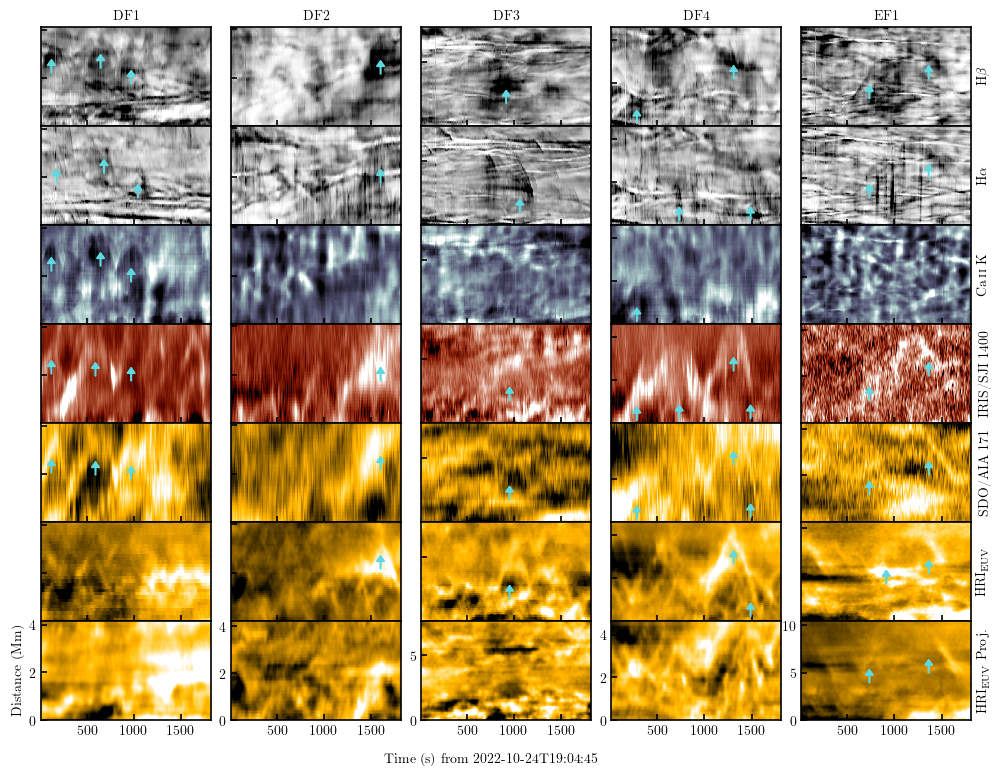

In [24]:
plt.close("all")
with plt.rc_context(ms_style_dict):
    fig, axes = plt.subplots(7, 5, figsize=(12, 9), gridspec_kw={"hspace": 0, "wspace": 0.12})

    for jj in range(5):
        for ii in range(6):
            axes[ii, jj].sharex(axes[6, jj])
            axes[ii, jj].tick_params(labelbottom=False, labelleft=False)
        
    plot_slit_data(slit_data_df1, axes[:,0], slit_length_extent_df1,
    norms=[
        percentile_norm(2, 99, slit_data_df1[0], 0.6),
        percentile_norm(1, 99, slit_data_df1[1], 0.6),
        percentile_norm(1, 99, slit_data_df1[2], 1),
        percentile_norm(1, 98, slit_data_df1[3], 0.2),
        percentile_norm(1, 99, slit_data_df1[4], 0.5),
        percentile_norm(1, 99, slit_data_df1[5], 0.4),
        percentile_norm(1, 90, slit_data_df1[6], 0.7),
    ])

    plot_slit_data(slit_data_df2, axes[:,1], slit_length_extent_df2,
    norms=[
        percentile_norm(2, 99, slit_data_df2[0], 0.6),
        percentile_norm(1, 99, slit_data_df2[1], 0.6),
        percentile_norm(1, 99, slit_data_df2[2], 1),
        percentile_norm(1, 98, slit_data_df2[3], 0.2),
        percentile_norm(1, 99, slit_data_df2[4], 0.5),
        percentile_norm(1, 99, slit_data_df2[5], 0.4),
        percentile_norm(1, 99, slit_data_df2[6], 0.4),
    ])

    plot_slit_data(slit_data_df3, axes[:,2], slit_length_extent_df3,
    norms=[
        percentile_norm(2, 99, slit_data_df3[0], 0.6),
        percentile_norm(1, 99, slit_data_df3[1], 0.6),
        percentile_norm(1, 99, slit_data_df3[2], 1),
        percentile_norm(1, 98, slit_data_df3[3], 0.2),
        percentile_norm(2, 99, slit_data_df3[4], 0.6),
        percentile_norm(1, 99, slit_data_df3[5], 0.4),
        percentile_norm(1, 99, slit_data_df3[6], 0.4),
    ])

    plot_slit_data(slit_data_df4, axes[:,3], slit_length_extent_df4,
    norms=[
        percentile_norm(2, 99, slit_data_df4[0], 0.6),
        percentile_norm(1, 99, slit_data_df4[1], 0.6),
        percentile_norm(1, 99, slit_data_df4[2], 1),
        percentile_norm(1, 98, slit_data_df4[3], 0.2),
        percentile_norm(2, 95, slit_data_df4[4], 0.7),
        percentile_norm(1, 99, slit_data_df4[5], 0.5),
        percentile_norm(1, 99, slit_data_df4[6], 0.4),
    ])

    plot_slit_data(slit_data_ef1, axes[:,4], slit_length_extent_ef1,
    norms=[
        percentile_norm(2, 99, slit_data_ef1[0], 0.6),
        percentile_norm(1, 99, slit_data_ef1[1], 0.6),
        percentile_norm(1, 99, slit_data_ef1[2], 1),
        percentile_norm(2, 98, slit_data_ef1[3], 0.3),
        percentile_norm(1, 99, slit_data_ef1[4], 0.5),
        percentile_norm(1, 95, slit_data_ef1[5], 0.8),
        percentile_norm(1, 99, slit_data_ef1[6], 0.4),
    ])

    for axes_i, axes_j, arrow_x, arrow_y in zip(axes_i_list, axes_j_list, arrow_x_list, arrow_y_list):
        axes[axes_i, axes_j].annotate("",
            xy=(arrow_x, arrow_y), xycoords="axes fraction",
            xytext=(arrow_x, arrow_y-0.2), textcoords="axes fraction",
            arrowprops=dict(arrowstyle="-|>, head_length={:.3f}, head_width={:.3f}".format(0.7/2, 0.5/2),
            color="#5FD9DF", lw=1.5,),
        )

    fig.supxlabel(f"Time (s) from {aia171_date_obs[aia_start_index].strftime('%Y-%m-%dT%H:%M:%S')}",
        y=0.06,fontsize=10)
    axes[6,0].set_ylabel(f"Distance (Mm)", fontsize=10)

    axes[0,4].set_ylabel(r"H$\beta$")
    axes[1,4].set_ylabel(r"H$\alpha$")
    axes[2,4].set_ylabel(r"Ca\,\textsc{ii} K")
    axes[3,4].set_ylabel(r"IRIS/SJI 1400")
    axes[4,4].set_ylabel(r"SDO/AIA 171")
    axes[5,4].set_ylabel(r"HRI\textsubscript{EUV}")
    axes[6,4].set_ylabel(r"HRI\textsubscript{EUV} Proj.")

    for ax_ in axes[:,4]:
        ax_.yaxis.set_label_position("right")
    
    axes[0,0].set_title("DF1",fontsize=10)
    axes[0,1].set_title("DF2",fontsize=10)
    axes[0,2].set_title("DF3",fontsize=10)
    axes[0,3].set_title("DF4",fontsize=10)
    axes[0,4].set_title("EF1",fontsize=10)

    fig.savefig("../../figs/ms_figure/fibril_spacetime.pdf", dpi=300, bbox_inches="tight")
    fig.savefig("../../figs/ms_figure_png/fibril_spacetime.png", dpi=300, bbox_inches="tight")
    plt.show(fig)

## Figure 5
---
Time-distance diagrams of fibril motions along artificial slits DF1-3 outlined in [Figure 2](./all_channel_layout.ipynb). From top to bottom: VBI-B H$\beta$, VBI-R H$\alpha$, VBI-B Ca II K, IRIS/SJI 1400, SDO/AIA 171, HRI\textsubscript{EUV}, and reprojected HRI\textsc{EUV}. The cyan arrows indicate potential corresponding fibril-like dynamics across different channels, including ascending and descending phases, and the apex of the fibril trajectory. Note that the artificial slits placed on the original HRIEUV images (also see [Figure 2b](./all_channel_layout.ipynb)) are adjusted with respect to others.

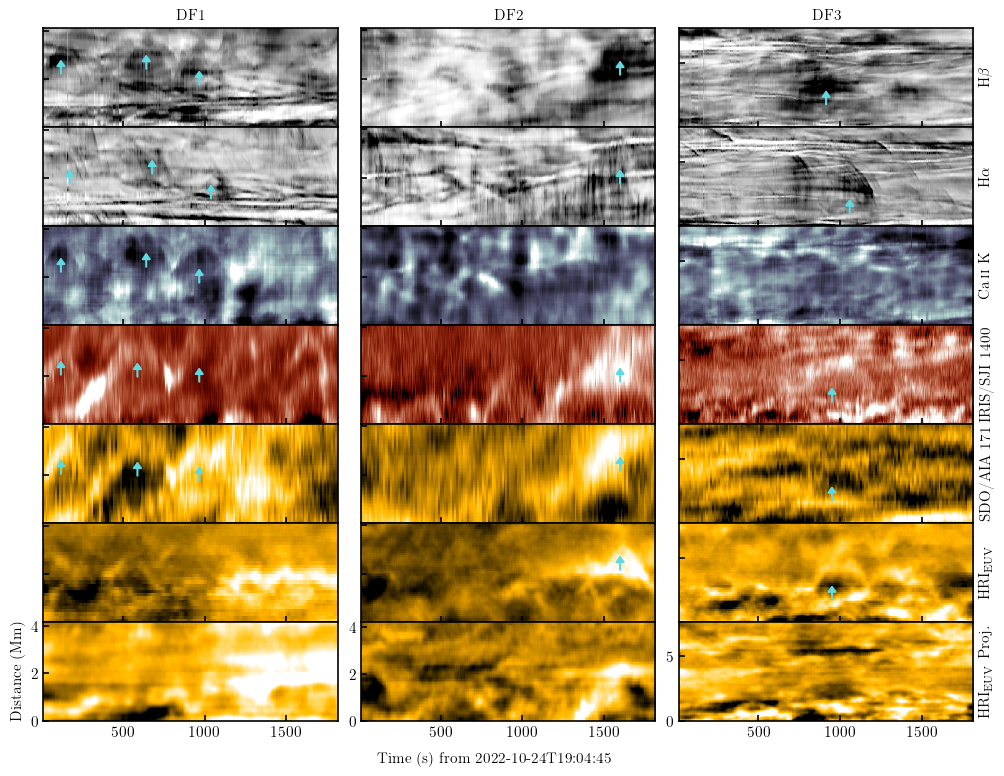

In [46]:
plt.close("all")
with plt.rc_context(ms_style_dict):
    fig, axes = plt.subplots(7, 3, figsize=(12, 9), gridspec_kw={"hspace": 0, "wspace": 0.08})

    for jj in range(3):
        for ii in range(6):
            axes[ii, jj].sharex(axes[6, jj])
            axes[ii, jj].tick_params(labelbottom=False, labelleft=False)
        
    plot_slit_data(slit_data_df1, axes[:,0], slit_length_extent_df1,
    norms=[
        percentile_norm(2, 99, slit_data_df1[0], 0.6),
        percentile_norm(1, 99, slit_data_df1[1], 0.6),
        percentile_norm(1, 99, slit_data_df1[2], 1),
        percentile_norm(1, 98, slit_data_df1[3], 0.2),
        percentile_norm(1, 99, slit_data_df1[4], 0.5),
        percentile_norm(1, 99, slit_data_df1[5], 0.4),
        percentile_norm(1, 90, slit_data_df1[6], 0.7),
    ])

    plot_slit_data(slit_data_df2, axes[:,1], slit_length_extent_df2,
    norms=[
        percentile_norm(2, 99, slit_data_df2[0], 0.6),
        percentile_norm(1, 99, slit_data_df2[1], 0.6),
        percentile_norm(1, 99, slit_data_df2[2], 1),
        percentile_norm(1, 98, slit_data_df2[3], 0.2),
        percentile_norm(1, 99, slit_data_df2[4], 0.5),
        percentile_norm(1, 99, slit_data_df2[5], 0.4),
        percentile_norm(1, 99, slit_data_df2[6], 0.4),
    ])

    plot_slit_data(slit_data_df3, axes[:,2], slit_length_extent_df3,
    norms=[
        percentile_norm(2, 99, slit_data_df3[0], 0.6),
        percentile_norm(1, 99, slit_data_df3[1], 0.6),
        percentile_norm(1, 99, slit_data_df3[2], 1),
        percentile_norm(1, 98, slit_data_df3[3], 0.2),
        percentile_norm(2, 99, slit_data_df3[4], 0.6),
        percentile_norm(1, 99, slit_data_df3[5], 0.4),
        percentile_norm(1, 99, slit_data_df3[6], 0.4),
    ])

    for axes_i, axes_j, arrow_x, arrow_y in zip(axes_i_list, axes_j_list, arrow_x_list, arrow_y_list):
        if axes_j < 3:
            axes[axes_i, axes_j].annotate("",
                xy=(arrow_x, arrow_y), xycoords="axes fraction",
                xytext=(arrow_x, arrow_y-0.2), textcoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>, head_length={:.3f}, head_width={:.3f}".format(0.7/2, 0.5/2),
                color="#5FD9DF", lw=1.5,),
            )

    fig.supxlabel(f"Time (s) from {aia171_date_obs[aia_start_index].strftime('%Y-%m-%dT%H:%M:%S')}",
        y=0.06,fontsize=11)
    axes[6,0].set_ylabel(f"Distance (Mm)", fontsize=11)

    axes[0,2].set_ylabel(r"H$\beta$", fontsize=11)
    axes[1,2].set_ylabel(r"H$\alpha$", fontsize=11)
    axes[2,2].set_ylabel(r"Ca\,\textsc{ii} K", fontsize=11)
    axes[3,2].set_ylabel(r"IRIS/SJI 1400", fontsize=11)
    axes[4,2].set_ylabel(r"SDO/AIA 171", fontsize=11)
    axes[5,2].set_ylabel(r"HRI\textsubscript{EUV}", fontsize=11)
    axes[6,2].set_ylabel(r"HRI\textsubscript{EUV} Proj.", fontsize=11)

    for ax_ in axes[6,:]:
        ax_.tick_params(which="both", labelsize=11)

    for ax_ in axes[:,2]:
        ax_.yaxis.set_label_position("right")
    
    axes[0,0].set_title("DF1",fontsize=11)
    axes[0,1].set_title("DF2",fontsize=11)
    axes[0,2].set_title("DF3",fontsize=11)

    fig.savefig("../../figs/ms_figure/fibril_spacetime_part_1.pdf", dpi=300, bbox_inches="tight")
    fig.savefig("../../figs/ms_figure_png/fibril_spacetime_part_1.png", dpi=300, bbox_inches="tight")
    plt.show(fig)

## Figure 6
---
Same as Figure 5 but for slits DF4, EF1, and EF2. 

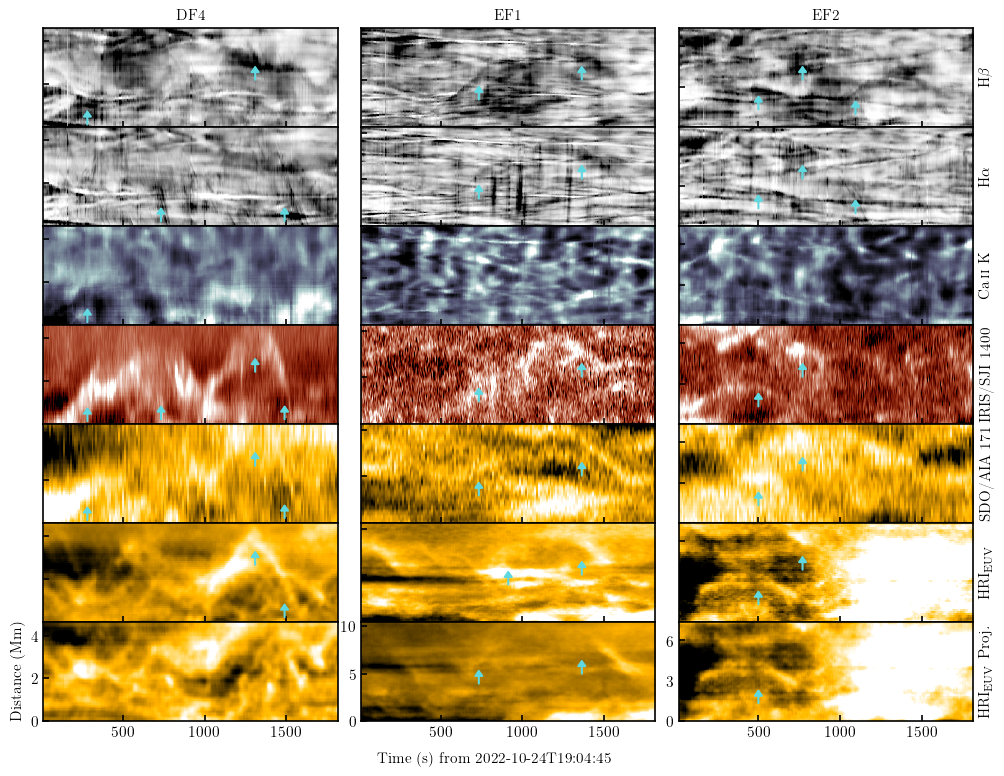

In [85]:
plt.close("all")
with plt.rc_context(ms_style_dict):
    fig, axes = plt.subplots(7, 3, figsize=(12, 9), gridspec_kw={"hspace": 0, "wspace": 0.08})

    for jj in range(3):
        for ii in range(6):
            axes[ii, jj].sharex(axes[6, jj])
            axes[ii, jj].tick_params(labelbottom=False, labelleft=False)

    plot_slit_data(slit_data_df4, axes[:,0], slit_length_extent_df4,
    norms=[
        percentile_norm(2, 99, slit_data_df4[0], 0.6),
        percentile_norm(1, 99, slit_data_df4[1], 0.6),
        percentile_norm(1, 99, slit_data_df4[2], 1),
        percentile_norm(1, 98, slit_data_df4[3], 0.2),
        percentile_norm(2, 95, slit_data_df4[4], 0.7),
        percentile_norm(1, 99, slit_data_df4[5], 0.5),
        percentile_norm(1, 99, slit_data_df4[6], 0.4),
    ])

    plot_slit_data(slit_data_ef1, axes[:,1], slit_length_extent_ef1,
    norms=[
        percentile_norm(2, 99, slit_data_ef1[0], 0.6),
        percentile_norm(1, 99, slit_data_ef1[1], 0.6),
        percentile_norm(1, 99, slit_data_ef1[2], 1),
        percentile_norm(2, 98, slit_data_ef1[3], 0.3),
        percentile_norm(1, 99, slit_data_ef1[4], 0.5),
        percentile_norm(1, 95, slit_data_ef1[5], 0.8),
        percentile_norm(1, 99, slit_data_ef1[6], 0.4),
    ])

    plot_slit_data(
        slit_data_ef2, axes[:,2], slit_length_extent_ef2,
        norms=[
            percentile_norm(2, 99, slit_data_ef2[0], 0.6),
            percentile_norm(1, 99, slit_data_ef2[1], 0.6),
            percentile_norm(1, 99, slit_data_ef2[2], 1),
            percentile_norm(2, 98, slit_data_ef2[3], 0.3),
            percentile_norm(1, 99, slit_data_ef2[4], 0.5),
            percentile_norm(4, 70, slit_data_ef2[5], 0.6),
            percentile_norm(4, 70, slit_data_ef2[6], 0.6),
        ]
    )

    for axes_i, axes_j, arrow_x, arrow_y in zip(axes_i_list, axes_j_list, arrow_x_list, arrow_y_list):
        if axes_j > 2:
            axes_j = axes_j - 3
            axes[axes_i, axes_j].annotate("",
                xy=(arrow_x, arrow_y), xycoords="axes fraction",
                xytext=(arrow_x, arrow_y-0.2), textcoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>, head_length={:.3f}, head_width={:.3f}".format(0.7/2, 0.5/2),
                color="#5FD9DF", lw=1.5,),
            )

    fig.supxlabel(f"Time (s) from {aia171_date_obs[aia_start_index].strftime('%Y-%m-%dT%H:%M:%S')}",
        y=0.06,fontsize=11)
    axes[6,0].set_ylabel(f"Distance (Mm)", fontsize=11)

    axes[0,2].set_ylabel(r"H$\beta$", fontsize=11)
    axes[1,2].set_ylabel(r"H$\alpha$", fontsize=11)
    axes[2,2].set_ylabel(r"Ca\,\textsc{ii} K", fontsize=11)
    axes[3,2].set_ylabel(r"IRIS/SJI 1400", fontsize=11)
    axes[4,2].set_ylabel(r"SDO/AIA 171", fontsize=11)
    axes[5,2].set_ylabel(r"HRI\textsubscript{EUV}", fontsize=11)
    axes[6,2].set_ylabel(r"HRI\textsubscript{EUV} Proj.", fontsize=11)

    for ax_ in axes[:,2]:
        ax_.yaxis.set_label_position("right")

    for ax_ in axes[6,:]:
        ax_.tick_params(which="both", labelsize=11)
    
    for ax_ in axes[:,2]:
        ax_.set_yticks([0,3,6])
    
    axes[0,0].set_title("DF4",fontsize=11)
    axes[0,1].set_title("EF1",fontsize=11)
    axes[0,2].set_title("EF2",fontsize=11)

    fig.savefig("../../figs/ms_figure/fibril_spacetime_part_2.pdf", dpi=300, bbox_inches="tight")
    fig.savefig("../../figs/ms_figure_png/fibril_spacetime_part_2.png", dpi=300, bbox_inches="tight")
    plt.show(fig)